# Statistical Modelling Project II: Planning a Term Under Uncertainty

Project I asked what drives exam scores. This project asks a different
question given that model: **how should a student spend a limited term to
get the best result?**

It reuses Project I's fitted coefficients and dataset wherever possible, and
clearly flags every additional number as an assumption made for this project.
The same underlying scenario is modelled at increasing levels of realism:

1. **Scenario**: parameters and what each one is based on.
2. **LP baseline**: the best plan if the world were deterministic and linear.
3. **MDP**: the exact optimal policy once outcomes are uncertain and
   decisions are sequential.
4. **MCTS**: approximate planning by simulation, validated against the MDP's
   exact answer.
5. **Risk-sensitive extension**: maximising the chance of reaching a target
   grade, rather than the average score.
6. **Results**: a side-by-side comparison of all four approaches.
7. **Recommendations**: what the plan means for the student.

Random seed fixed at 42 throughout, so every number here is reproducible.

## 1. Scenario

Every parameter used from here on falls into one of two categories, and both
are kept visibly separate throughout this notebook and in `code/common.py`:

- **From Project I**: a real, fitted number (or a real descriptive statistic
  of Project I's dataset), taken as given.
- **Assumption for this project**: a choice made to turn Project I's
  regression into a concrete planning scenario. Project I never modelled
  decisions or time, so these numbers do not exist anywhere until this
  project defines them.

The one genuinely new descriptive statistic needed at this stage is the mean
weekly study hours across Project I's 320 students. Project I's Group study
and Tutoring effects are a fixed points-per-week bonus for using that method
at all, not a per-hour rate, so Stage 1's hours-allocation linear programme
needs them converted to a per-hour premium. That conversion divides each
dummy coefficient by this mean, which is why it is computed here rather than
simply assumed.

In [1]:
import sys
sys.path.append("../code")

import pandas as pd
import common

df = common.load_student_data()
print(f"Students in Project I's dataset: {len(df)}")
print(f"Mean weekly study hours: {common.MEAN_WEEKLY_STUDY_HOURS}")
df.head()

Students in Project I's dataset: 320
Mean weekly study hours: 11.9094


,student_id,study_hours_per_week,attendance_rate,sleep_hours,prior_gpa,extracurricular_hours,study_method,exam_score
0,S0001,13.28,66.5,7.48,3.38,1,Group study,53.2
1,S0002,6.53,77.5,6.68,2.79,3,Self-study,58.6
2,S0003,15.69,92.8,6.81,3.62,5,Self-study,92.0
3,S0004,8.39,82.9,5.91,3.18,4,Self-study,67.3
4,S0005,11.22,70.1,8.14,2.94,3,Self-study,56.9


### Parameter table: from Project I vs assumption for this project

The table below is generated directly from `code/common.py`, so it can never
drift out of sync with the values the rest of this notebook actually uses.

In [2]:
rows = [
    ("Mean weekly study hours", common.MEAN_WEEKLY_STUDY_HOURS, "From Project I (dataset mean)"),
    ("Study hours coefficient (points per hour)", common.PROJECT_I_STUDY_HOURS_COEF, "From Project I (fitted)"),
    ("Attendance coefficient (points per pp)", common.PROJECT_I_ATTENDANCE_COEF, "From Project I (fitted)"),
    ("Prior GPA coefficient (points per GPA point)", common.PROJECT_I_PRIOR_GPA_COEF, "From Project I (fitted)"),
    ("Extracurricular coefficient (points per hour)", common.PROJECT_I_EXTRACURRICULAR_COEF, "From Project I (fitted)"),
    ("Group study dummy (points per week)", common.PROJECT_I_GROUP_STUDY_DUMMY, "From Project I (fitted)"),
    ("Tutoring dummy (points per week)", common.PROJECT_I_TUTORING_DUMMY, "From Project I (fitted)"),
    ("Sleep coefficient, estimated (not significant)", common.PROJECT_I_SLEEP_COEF_ESTIMATED, "From Project I (fitted)"),
    ("Sleep penalty, true generating value", common.TRUE_SLEEP_PENALTY_PER_HOUR_BELOW_6, "From Project I (true, generating)"),
    ("Exam score noise SD", common.TRUE_NOISE_SD, "From Project I (true, generating)"),
    ("Group study premium per hour", round(common.LP_GROUP_STUDY_PREMIUM_PER_HOUR, 4), "Assumption (derived: dummy / mean hours)"),
    ("Tutoring premium per hour", round(common.LP_TUTORING_PREMIUM_PER_HOUR, 4), "Assumption (derived: dummy / mean hours)"),
    ("Weekly hours budget", common.LP_TOTAL_HOURS_BUDGET, "Assumption"),
    ("Tutoring hours cap", common.LP_TUTORING_MAX_HOURS, "Assumption"),
    ("Group study hours cap", common.LP_GROUP_STUDY_MAX_HOURS, "Assumption"),
    ("Scheduled lecture hours", common.LP_SCHEDULED_LECTURE_HOURS, "Assumption"),
    ("Extracurricular minimum hours", common.LP_EXTRACURRICULAR_MIN_HOURS, "Assumption"),
    ("Term length (weeks)", common.MDP_TERM_WEEKS, "Assumption"),
    ("Knowledge scale (0 to k_max)", common.MDP_KNOWLEDGE_MAX, "Assumption"),
    ("Tutoring sessions available", common.MDP_TUTORING_SESSIONS_MAX, "Assumption"),
    ("Starting state (t, k, f, s)", tuple(common.MDP_START_STATE.values()), "Assumption"),
    ("P(self-study gains +1 knowledge)", common.MDP_P_SELF_STUDY, "Assumption (baseline)"),
    ("P(group study gains +1 knowledge)", common.MDP_P_GROUP_STUDY, "Assumption (ratio anchored to Project I)"),
    ("P(tutoring gains +1 / +2 knowledge)", (common.MDP_P_TUTORING_PLUS1, common.MDP_P_TUTORING_PLUS2), "Assumption (ratio anchored to Project I)"),
    ("Fatigue success multipliers (fresh, tired, exhausted)", tuple(common.MDP_FATIGUE_FACTOR.values()), "Assumption"),
    ("P(studying raises fatigue by 1)", common.MDP_P_FATIGUE_INCREASE, "Assumption"),
    ("Terminal score at k = 0 / k = 10", (common.terminal_expected_score(0), common.terminal_expected_score(10)), "Assumption (calibrated to Project I's score range)"),
    ("Risk-sensitive target grade", common.RISK_TARGET_GRADE, "Assumption (example: a scholarship threshold)"),
]
param_table = pd.DataFrame(rows, columns=["Parameter", "Value", "Source"])
param_table

,Parameter,Value,Source
0,Mean weekly study hours,11.9094,From Project I (dataset mean)
1,Study hours coefficient (points per hour),1.13,From Project I (fitted)
2,Attendance coefficient (points per pp),0.28,From Project I (fitted)
3,Prior GPA coefficient (points per GPA point),7.73,From Project I (fitted)
4,Extracurricular coefficient (points per hour),-0.52,From Project I (fitted)
5,Group study dummy (points per week),1.83,From Project I (fitted)
6,Tutoring dummy (points per week),5.56,From Project I (fitted)
7,"Sleep coefficient, estimated (not significant)",0.4,From Project I (fitted)
8,"Sleep penalty, true generating value",-1.8,"From Project I (true, generating)"
9,Exam score noise SD,7.5,"From Project I (true, generating)"


## 2. LP baseline

**Plain-language finding first:** if hours simply added up with no diminishing
returns and no uncertainty, the best plan is not a balanced spread. It is to
max out every capped, high-value activity (lecture, tutoring, group study)
and pour every remaining hour into self-study, hitting the weekly budget
exactly. That "all or nothing" shape, not a balanced timetable, is the
signature of a linear model, and it is the reason Stage 2 introduces
diminishing returns and uncertainty.

### The linear programme

Decision variables (hours per week): self-study $x_1$, group study $x_2$,
tutoring $x_3$, lecture $x_4$, extracurricular $x_5$.

$$
\begin{aligned}
\text{maximise} \quad & 1.13 x_1 + 1.2837 x_2 + 1.5969 x_3 + 1.8667 x_4 - 0.52 x_5 \\
\text{subject to} \quad & x_1 + x_2 + x_3 + x_4 + x_5 \le 40 \\
& x_3 \le 3 \\
& x_2 \le 6 \\
& x_4 \le 15 \\
& x_5 \ge 2 \\
& x_1, x_2, x_3, x_4, x_5 \ge 0
\end{aligned}
$$

The coefficients on $x_2$ and $x_3$ are Project I's Group study and Tutoring
bonuses (a fixed points-per-week premium for using that method at all)
converted to a per-hour premium by dividing by the mean weekly study hours
in Project I's dataset (an assumption for this project, documented in
`common.py`). The coefficient on $x_4$ is Project I's attendance coefficient
rescaled from percentage points to lecture hours, given 15 scheduled hours a
week.

In [3]:
import importlib
lp = importlib.import_module("01_lp")

result, coefs, A_ub, b_ub = lp.build_lp()
allocation = dict(zip(lp.VARS, result.x))
for v in lp.VARS:
    print(f"{lp.VAR_LABELS[v]}: {allocation[v]:.1f} hours")
print(f"\nPredicted score: {lp.predicted_score(allocation):.2f}")

Self-study: 14.0 hours
Group study: 6.0 hours
Tutoring: 3.0 hours
Lecture: 15.0 hours
Extracurricular: 2.0 hours

Predicted score: 66.23


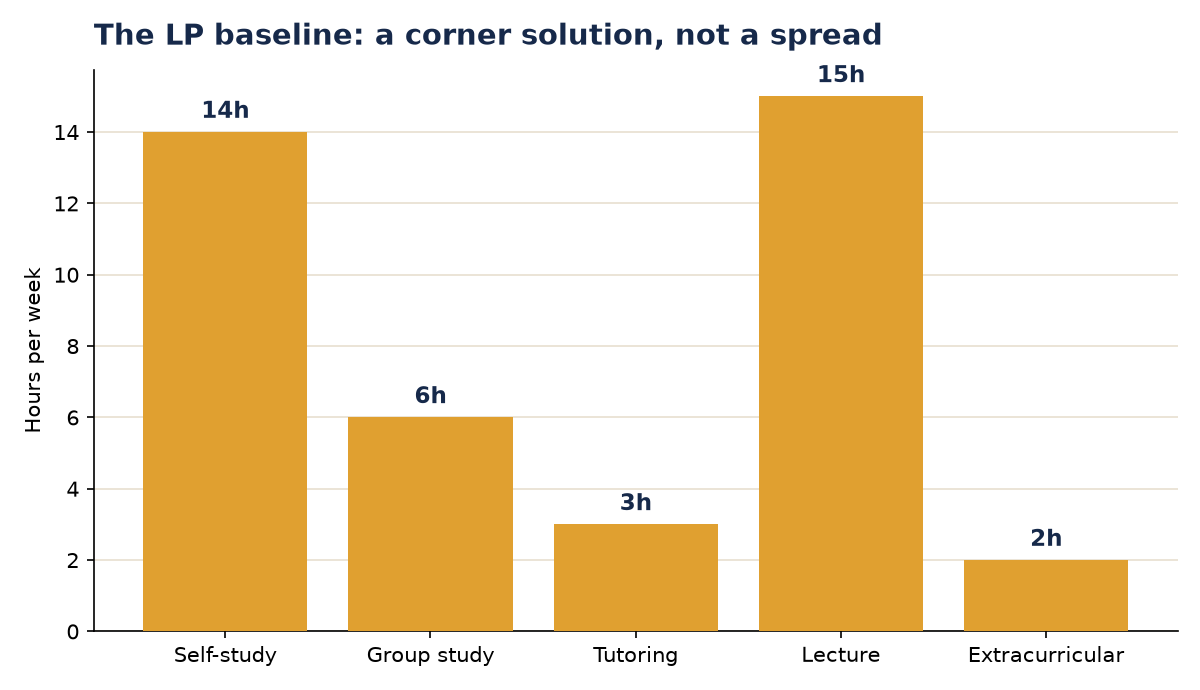

In [4]:
lp.plot_allocation(allocation, "../images/01_lp_allocation.png")
from IPython.display import Image
Image("../images/01_lp_allocation.png")

### Shadow prices: what one more hour of each resource is worth

A shadow price is the rate of change in the optimal score if a constraint
were relaxed by one unit, holding everything else fixed.

In [5]:
shadow = lp.shadow_prices(result)
for name, price in shadow.items():
    print(f"{name}: {price:+.4f} points")

Weekly hours budget: +1.1300 points
Tutoring hours cap: +0.4669 points
Group study hours cap: +0.1537 points
Lecture hours cap: +0.7367 points
Extracurricular minimum: +1.6500 points


In plain words: the weekly hours budget is worth **1.13 points per extra
hour**, exactly the self-study rate, because self-study is the activity
still absorbing spare hours once everything else is capped or at its
minimum. Relaxing the tutoring cap by one session is worth **0.4669
points**, the premium tutoring has over self-study. The extracurricular
minimum is the most expensive constraint by far, at **1.65 points per
hour** were it relaxed downward, since every hour freed from
extracurricular both stops losing 0.52 points and starts earning 1.13
points at self-study, a swing of 1.65.

### Validation

Two independent checks, plus a numeric constraint check.

In [6]:
# Check 1: shadow price of the weekly budget, confirmed by re-solving at 41 hours
result41, _, _, _ = lp.build_lp(41)
allocation41 = dict(zip(lp.VARS, result41.x))
score_40 = lp.predicted_score(allocation)
score_41 = lp.predicted_score(allocation41)
print(f"Score at 40 hours: {score_40:.4f}")
print(f"Score at 41 hours: {score_41:.4f}")
print(f"Actual increase: {score_41 - score_40:.4f}")
print(f"Shadow price predicted: {shadow['Weekly hours budget']:.4f}")
print(f"Match: {abs((score_41 - score_40) - shadow['Weekly hours budget']) < 1e-6}")

Score at 40 hours: 66.2325
Score at 41 hours: 67.3625
Actual increase: 1.1300
Shadow price predicted: 1.1300
Match: True


In [7]:
# Check 2: coarse brute-force grid search over feasible allocations
grid = lp.brute_force_grid_search()
lp_decision_score = lp.predicted_score(allocation) - lp.common.PROJECT_I_INTERCEPT
print(f"Grid search best decision-only score: {grid['decision_score']:.4f}")
print(f"LP decision-only score:               {lp_decision_score:.4f}")
print(f"Match: {abs(grid['decision_score'] - lp_decision_score) < 1e-6}")

Grid search best decision-only score: 55.2725
LP decision-only score:               55.2725
Match: True


In [8]:
# Check 3: every constraint satisfied numerically
total_hours = sum(allocation.values())
print(f"Total hours used: {total_hours:.4f} (budget 40): {total_hours <= 40 + 1e-9}")
print(f"Tutoring: {allocation['tutoring']:.4f} (cap 3): {allocation['tutoring'] <= 3 + 1e-9}")
print(f"Group study: {allocation['group_study']:.4f} (cap 6): {allocation['group_study'] <= 6 + 1e-9}")
print(f"Lecture: {allocation['lecture']:.4f} (cap 15): {allocation['lecture'] <= 15 + 1e-9}")
print(f"Extracurricular: {allocation['extracurricular']:.4f} (min 2): {allocation['extracurricular'] >= 2 - 1e-9}")
print(f"All non-negative: {all(v >= -1e-9 for v in allocation.values())}")

Total hours used: 40.0000 (budget 40): True
Tutoring: 3.0000 (cap 3): True
Group study: 6.0000 (cap 6): True
Lecture: 15.0000 (cap 15): True
Extracurricular: 2.0000 (min 2): True
All non-negative: True


### Sensitivity: how the optimal score changes with the weekly budget

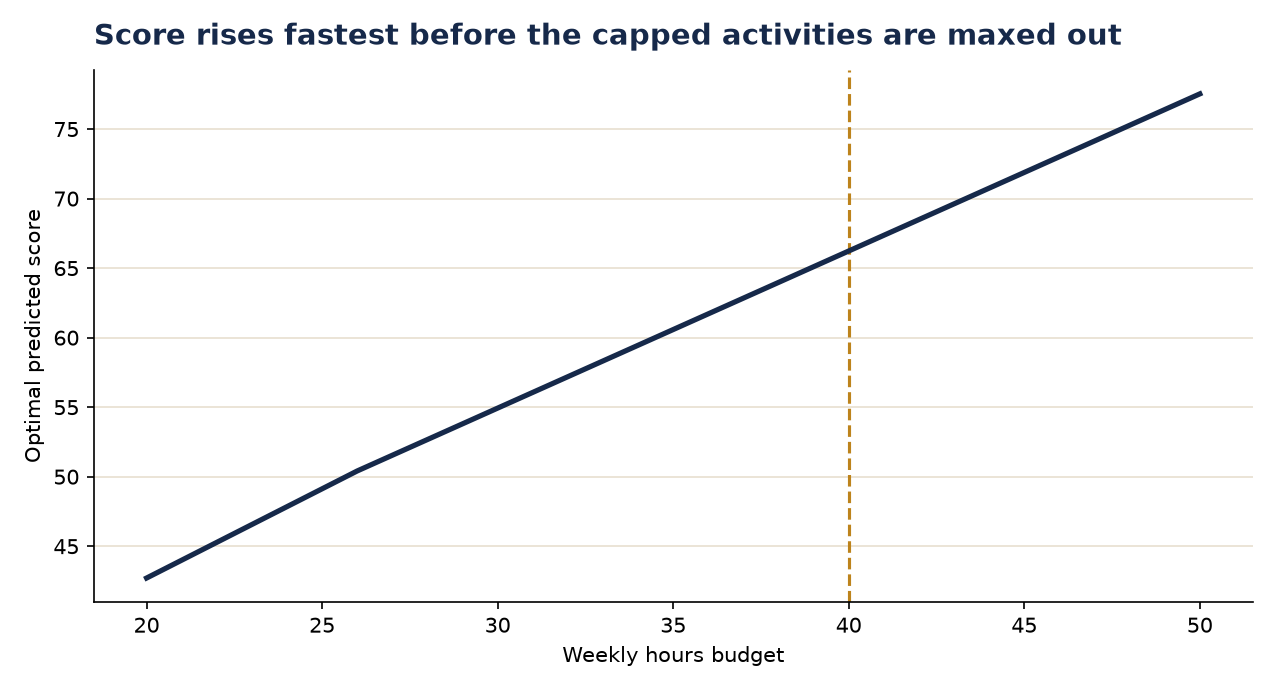

In [9]:
sweep = lp.sensitivity_sweep()
lp.plot_sensitivity(sweep, "../images/02_lp_sensitivity.png")
Image("../images/02_lp_sensitivity.png")

### Why this motivates Stage 2

The LP's answer is a corner solution: every hour flows to the
highest-return activity until a constraint binds, then the next
highest, and so on, with nothing left in reserve. That happens because
the objective is linear (no diminishing returns to an hour of tutoring,
no cost to sequencing) and there is no uncertainty (an hour of self-study
always returns exactly 1.13 points). Neither is true of an actual term:
fatigue makes additional study less effective, study can fail to produce
learning at all, and a student's state (how much they already know, how
tired they are, how many tutoring sessions remain) changes week to week.
Stage 2 models the same scenario as a sequential decision problem under
uncertainty, which is where a corner solution stops being the obvious
answer.

## 3. MDP

*To be built in Phase 3.*

## 4. MCTS

*To be built in Phase 4.*

## 5. Risk-sensitive extension

*To be built in Phase 5.*

## 6. Results

*To be built in Phase 6.*

## 7. Recommendations

*To be built in Phase 6.*